<a href="https://colab.research.google.com/github/dxcim/Business-Analytics-Foundations/blob/main/rooster_a14.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Module 4 | Pattern discovery**

`rooster_a14.ipynb` | 2025-04-03 17:32

# Rooster products

# Rooster repeat purchases

Repeat purchases by customers are important for Rooster, and they would like to understand the factors that influence repeat purchases. In this notebook, we will use PyCaret to build a model to predict whether a customer will be a repeat customer or not.

For each **Analysis task**, write code to do the task in the code cell provided.

For each **Reporting task**, write your brief answer in the same cell as the question.

## How to use this notebook


To run this notebook in Colab, choose **Runtime** from the top menu and then **Run all**. This will set up the notebook and then run all the cells.

The first run may take a few minutes to install the required libraries and download the data. Subsequent runs will be faster.

You can also run the cells one by one using the play button next to each cell.

---

This section of the notebook contains code to set up the notebook environment. It installs the required libraries, downloads the data, and sets the display style for charts.

After this section of the notebook runs successfully, you can hide the cells in this section. To do this in Colab, choose **View** from the top menu, then **Collapse sections**, or click the downward chevron ⌄ next to the section title.

You do not need to understand the code in the "How to use this notebook" section to follow the rest of the notebook.


In [1]:
# install PyCaret

# if prompted by Colab, restart the runtime after installing: Runtime -> Restart session
# To restart the runtime, use the menu: Runtime menu -> Restart session
# or use the keyboard shortcut Ctrl-M then . (period) and confirm. Mac: ⌘-M then . (period).
# if you see: "ERROR: pip's dependency resolver does not currently take into account all the packages that are installed",
# and you have NOT tried restarting the runtime, you should restart the runtime. Otherwise, you can ignore this message.

# %pip install --upgrade --quiet pycaret

In [2]:
# download data

from urllib.request import urlretrieve
from pathlib import Path

if not Path("/content/rooster_a14_final.xlsx").exists():
    urlretrieve("https://canvas.uts.edu.au/files/9162667/download?download_frd=1&verifier=owNFECYwsotVvONSmUBiB6XDYBAyhn6J3LHQDdmm", "rooster_a14_final.xlsx")

In [3]:
# format figures for display in Canvas

import seaborn as sns

sns.set_theme(style="white", rc={"figure.figsize": (12, 6)})
sns.set_context("notebook", font_scale=1.25, rc={"lines.linewidth": 2.5})

# in Colab, if this cell fails with
# "ValueError: numpy.dtype size changed, may indicate binary incompatibility. Expected 96 from C header, got 88 from PyObject"
# first try restarting the runtime.
# To restart the runtime, use the menu: Runtime menu -> Restart runtime
# or use the keyboard shortcut Ctrl-M then . (period) and confirm. Mac: ⌘-M then . (period).
# Then re-run this cell.

## Load the data

We will use the same data as in the previous example, but this time we will use PyCaret to compare multiple models, build a final model, and evaluate the final model on the test set.

In [4]:
import pandas as pd

orders = pd.read_excel("/content/rooster_a14_final.xlsx", sheet_name="orders")
cols = ["customer_email", "order_number", "origin", "coupon_code"]
orders[cols].head()

,customer_email,order_number,origin,coupon_code
0,eml_0044f177@gmail.example.net,ord_1b08306c,Referral,NaN
1,eml_0118567b@gmail.example.net,ord_a462ea6d,Unknown,NaN
2,eml_0118567b@gmail.example.net,ord_4b79264b,Direct,NaN
3,eml_014964d7@gmail.example.net,ord_3493359d,Google,NaN
4,eml_015e4e4f@gmail.example.net,ord_5bfea360,Direct,NaN


## Data preparation

In [5]:
# we need, at customer level:
# - customer_email (unique identifier)
# - whether the customer is a repeat customer (multiple order numbers)
# - whether the first order used a coupon (first order's coupon_code is not null)
# - acquisition channel for the first order (origin)

# sort orders by customer_email and order_seq to ensure the first order is first
orders.sort_values(by=["customer_email", "order_seq"], inplace=True)

# group by customer_email and aggregate
customer_orders = orders.groupby("customer_email").agg(
    repeat_customer=("order_number", lambda x: x.nunique() > 1),
    first_order_acquisition_channel=("origin", "first"),
    first_order_coupon_code=("coupon_code", "first")
).reset_index()

# add a binary column for the first order coupon used
customer_orders["first_order_coupon_used"] = customer_orders["first_order_coupon_code"].notnull()

# show the first 15 rows
customer_orders.head(15)

,customer_email,repeat_customer,first_order_acquisition_channel,first_order_coupon_code,first_order_coupon_used
0,eml_0044f177@gmail.example.net,False,Referral,None,False
1,eml_0118567b@gmail.example.net,True,Unknown,None,False
2,eml_014964d7@gmail.example.net,False,Google,None,False
3,eml_015e4e4f@gmail.example.net,True,Direct,None,False
4,eml_01882a25@gmail.example.net,True,Facebook,None,False
5,eml_018c4609@gmail.example.net,False,Facebook,None,False
6,eml_01b46d5c@gmail.example.net,False,Unknown,ROOSTER10,True
7,eml_01b7a00a@gmail.example.net,True,Newsletter,ROOSTER5,True
8,eml_01c13bac@gmail.example.net,False,Facebook,None,False
9,eml_01f61a39@gmail.example.net,False,Facebook,CYBER15,True


## Holdout set

We will use 20% of the data as a holdout set for final evaluation of the model.

In [6]:
# split to holdout set

holdout = customer_orders.sample(frac=0.2, random_state=22804)
customer_orders.drop(holdout.index, inplace=True)

> [!activity] Analysis task
>
> How many customers are in the original dataset? How many customers are in the holdout set?

In [7]:
print("There are", len(customer_orders), "customers in the original ('customer_orders') dataframe ")
print("There are", len(holdout), "customers in the holdout dataframe ")

There are 1280 customers in the original ('customer_orders') dataframe 
There are 320 customers in the holdout dataframe 


## Exploratory data analysis

> [!activity] Analysis task
>
> Find the percentage of repeat customers in the dataset.

In [8]:
repeat_percent = customer_orders['repeat_customer'].sum()/len(customer_orders) * 100
print(f"The percentage of repeat customers is {repeat_percent}%")

The percentage of repeat customers is 48.59375%


> [!activity] Analysis task
>
> Find the percentage of repeat customers who used a coupon for their first order. You can choose to do this visually or numerically.

The percentage of repeat customers who used a coupon on their first order is 26.640625%


<Axes: xlabel='repeat_customer', ylabel='count'>

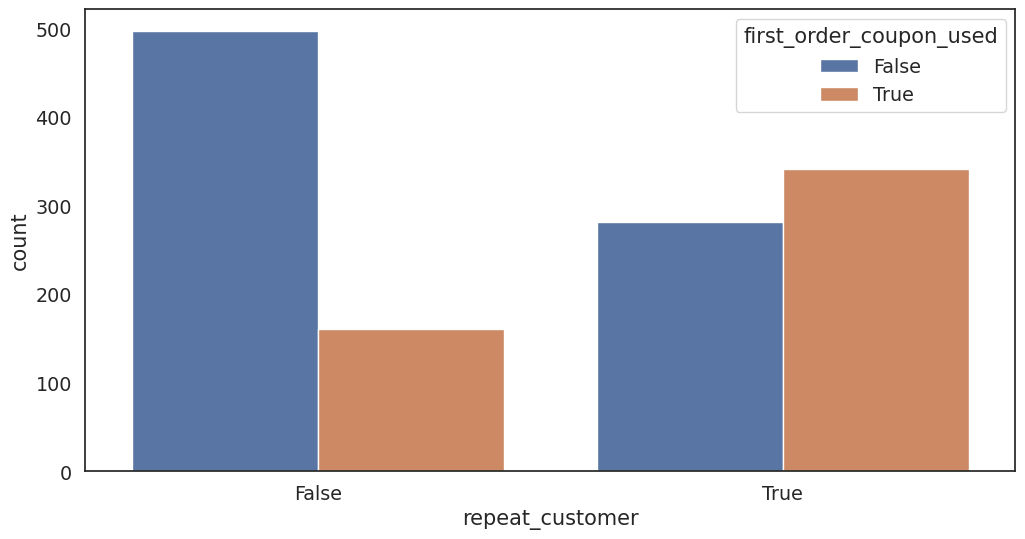

In [9]:
count_first_order_coupon_repeat = len(customer_orders[customer_orders['repeat_customer'] & customer_orders['first_order_coupon_used']])/len(customer_orders)*100
print(f"The percentage of repeat customers who used a coupon on their first order is {count_first_order_coupon_repeat}%")
sns.countplot(x='repeat_customer', hue='first_order_coupon_used', data=customer_orders)

> [!activity] Reporting task
>
> Summarise the results of the previous analysis tasks, and what pattern you would expect the model to learn. Consider the percentage of customers who are repeat customers or not, and the percentage of repeat customers who used a coupon for their first order.

## Data modelling

We will use PyCaret to compare multiple models, build a final model, and evaluate the final model on the test set.

First, set up the PyCaret classification session. We will use the `repeat_customer` column as the target variable, and ignore the `customer_email` and `first_order_coupon_code` columns.

In [28]:
from pycaret.classification import *

# set up a PyCaret classification session to predict customer churn
setup(data=customer_orders,
      target='repeat_customer',    # target variable
      ignore_features=['customer_email', 'first_order_coupon_code'],
      session_id=22804)  # For reproducibility

,Description,Value
0,Session id,22804
1,Target,repeat_customer
2,Target type,Binary
3,Original data shape,"(1280, 5)"
4,Transformed data shape,"(1280, 11)"
5,Transformed train set shape,"(896, 11)"
6,Transformed test set shape,"(384, 11)"
7,Ignore features,2
8,Categorical features,1
9,Rows with missing values,60.8%


> [!activity] Reporting task
>
> How many customers are in the test set?

There are **896 customers in the Test set**, as seen in the shape from the calcs above

We now have a PyCaret classification session set up. We can use the `compare_models()` function to compare multiple models and find the best one.

In [29]:
# compare models

# we will limit the models to a few common ones, because it halves the runtime
best_model = compare_models(sort='AUC', include=['lr', 'rf', 'dt', 'ridge', 'ada', 'lda'])

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
ridge,Ridge Classifier,0.6484,0.6535,0.5563,0.6644,0.6032,0.2928,0.2978,0.0530
ada,Ada Boost Classifier,0.6484,0.6534,0.5563,0.6644,0.6032,0.2928,0.2978,0.1440
lda,Linear Discriminant Analysis,0.6484,0.6532,0.5563,0.6644,0.6032,0.2928,0.2978,0.0770
lr,Logistic Regression,0.6484,0.6527,0.5563,0.6644,0.6032,0.2928,0.2978,0.0540
dt,Decision Tree Classifier,0.6418,0.6460,0.5517,0.6540,0.5963,0.2794,0.2836,0.0540
rf,Random Forest Classifier,0.6418,0.6458,0.5540,0.6536,0.5974,0.2795,0.2837,0.2180


Processing:   0%|          | 0/29 [00:00<?, ?it/s]

> [!activity] Reporting task
>
> What is the best model, and what metric did you use to evaluate this? Are the other models significantly different?

The best model is the **Ridge Classifier**, as it has the highest Accuracy and AUC (Area Under Curve) values. Almost all the other models have the exact same stats except in the AUC category, where Ridge marginally beats the other models

### Model evaluation



### Final model

We will specify a logistic regression model as the final model. We will use the `create_model()` function to create the model.

In [30]:
# build a logistic regression model

model = create_model('lr', verbose=False)

> [!activity] Analysis task
>
> Show the feature importance of the final model.

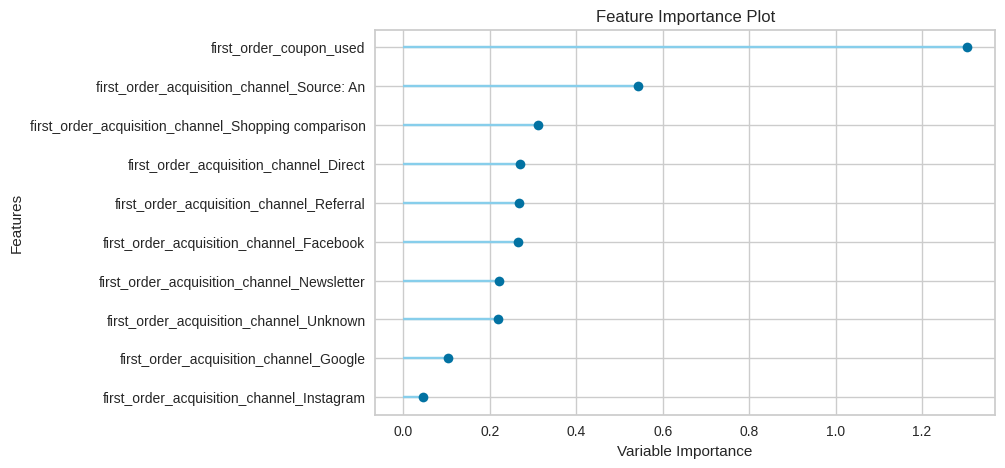

In [31]:
plot_model(model, plot='feature')

Now we'll evaluate the model on the test set. We will use the `evaluate_model()` function to evaluate the model.

In [14]:
# evaluate the model on the test set

test_predictions = predict_model(model)
print("Test prediction set size:", test_predictions.shape[0])

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Logistic Regression,0.6693,0.6685,0.5294,0.7174,0.6092,0.3337,0.3453


Test prediction set size: 384


We will also evaluate the model on the holdout set, and predict whether these customers are repeat customers.

In [15]:
# evaluate the model on the holdout set

predictions = predict_model(model, data=holdout)
print("Holdout prediction set size:", predictions.shape[0])

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Logistic Regression,0.6188,0.6489,0.5112,0.7222,0.5987,0.2553,0.2692


Holdout prediction set size: 320


> [!activity] Reporting task
>
> Compare the model's performance on the test set and the holdout set.

The Regression model performed as follows:

*   Test set
  *   Accuracy: 66.93%
  *   AUC (Area Under Curve): 66.85%

*   Holdout set
  *   Accuracy: 61.88%
  *   AUC (Area Under Curve): 64.89%

Based on these numbers we can see that the model performed better on the test set than on the holdout set. The model also outperformed itself when compared to the compare_models results {Accuracy: 64.84%, AUC:65.27%}

> [!activity] Analysis task
>
> Show the confusion matrix for the final model.

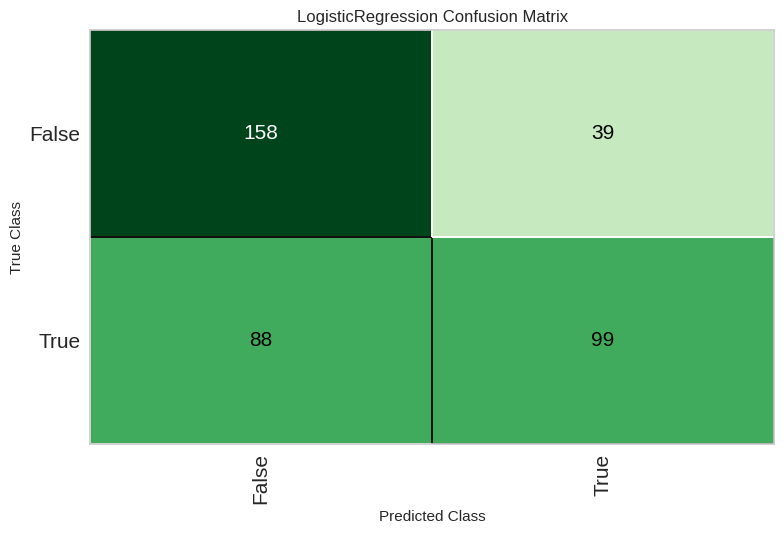

In [16]:
plot_model(model, plot='confusion_matrix')

> [!activity] Reporting task
>
> Which set of data does your confusion matrix relate to? Is it the entire original data, the combined training and testing sets, the training set, the testing set, or the holdout set?
> How many customers were predicted to be repeat customers, but were not actually repeat customers?

The confusion matrix plots a chart using the **holdout dataset** by default.

The number of customers predicted to be repeat customers but weren't actual repeat customers (false positives) is **39**.

> [!activity] Analysis task
>
> Show the first 10 predictions made using the holdout set.

In [17]:
# Show the first 10 rows of the predictions dataframe.

predictions.head(10)

,customer_email,first_order_acquisition_channel,first_order_coupon_code,first_order_coupon_used,repeat_customer,prediction_label,prediction_score
1052,eml_aafb9467@gmail.example.net,Shopping comparison,NaN,False,False,0,0.5774
930,eml_99676d78@gmail.example.net,Google,NaN,False,True,0,0.6742
1295,eml_cf12da66@gmail.example.net,Google,NaN,False,True,0,0.6742
1012,eml_a57eb702@gmail.example.net,Facebook,ROOSTER5,True,True,1,0.7205
48,eml_07c1d564@gmail.example.net,Shopping comparison,NaN,False,False,0,0.5774
711,eml_7564258f@gmail.example.net,Google,ROOSTER5,True,False,1,0.6403
754,eml_7cab2f73@gmail.example.net,Unknown,NaN,False,False,0,0.5999
674,eml_7081b11c@gmail.example.net,Unknown,NaN,False,True,0,0.5999
585,eml_60656ff1@gmail.example.net,Facebook,NaN,False,False,0,0.5884
1517,eml_f4de2440@gmail.example.net,Referral,NaN,False,True,0,0.5883


## Identifying target customers

Let's see how many customers were predicted to be repeat customers, but were not actually repeat customers.

We'll get overall counts of the predictions and actuals for the holdout set.

In [18]:
# tabulate the predictions and actuals for the holdout set
# basically a confusion matrix but not a matrix
# does that mean it's just a 'confusion'?

predictions.groupby(["prediction_label"])["repeat_customer"].value_counts()

prediction_label  repeat_customer
0                 False              107
                  True                87
1                 True                91
                  False               35
Name: count, dtype: int64

In [19]:
# we could get the same result with a crosstab, plus the convenience of row and column totals

pd.crosstab(predictions["prediction_label"], predictions["repeat_customer"], margins=True)

repeat_customer,False,True,All
prediction_label,,,
0,107,87,194
1,35,91,126
All,142,178,320


There are some customers who are not repeat customers, but the model predicted that they would be. Let's find them.

In [20]:
# find some customers who are not repeat customers, but the model predicts they will be
non_repeat = predictions[predictions["repeat_customer"] == 0]
predicted_to_repeat = non_repeat[non_repeat["prediction_label"] == 1]

# sort most likely to be repeat customers
predicted_to_repeat.sort_values(by="prediction_score", ascending=False, inplace=True)

# keep the top 15 of these customers
top_customers = predicted_to_repeat[['customer_email', 'prediction_score']].head(15)
top_customers.reset_index(inplace=True, drop=True) # just to make it look nice
top_customers

,customer_email,prediction_score
0,eml_a62c2c2b@gmail.example.net,0.7295
1,eml_9aec488c@gmail.example.net,0.7206
2,eml_b644b074@gmail.example.net,0.7206
3,eml_d14f9734@gmail.example.net,0.7206
4,eml_76bdab20@gmail.example.net,0.7206
5,eml_bf72fcc1@gmail.example.net,0.7205
6,eml_6b063e5c@gmail.example.net,0.7205
7,eml_622d4dda@gmail.example.net,0.7205
8,eml_4d682ede@gmail.example.net,0.7205
9,eml_01f61a39@gmail.example.net,0.7205


## Reporting and recommendations

> [!activity] Reporting task
>
> Is coupon usage important for predicting repeat customers? How can you tell? Explain the link between coupon usage and repeat orders to Rooster.

In [21]:
p_B_given_A_true = (customer_orders[customer_orders['first_order_coupon_used'] == True]['repeat_customer'] == True).mean()
p_B = (customer_orders['repeat_customer'] == True).mean()

print(f"If A is True, then B is {p_B_given_A_true / p_B:.2f} as likely to be True.")

If A is True, then B is 1.40 as likely to be True.


Yes, Coupon Usage is an important predictor for repeat customers. If a cusotmer uses a coupon on their first order, they are 1.4x more likely to place another order (i.e. be a repeat customer).

> [!activity] Reporting task
>
> Recommend a way for Rooster to use the list of customers you have made (`top_customers`).
>
> You made the list by selecting predictions that the model was wrong about. Explain to Rooster why a list of wrong predictions is useful to them.

--------------------------------------------------------------------------------

> I don't get the second part of the question. The 'top_customers' df shows customers by likelihood of being repeat customers, sorted in descending order by the prediction score

--------------------------------------------------------------------------------

> [!activity] Reporting task
>
> What further analysis could you do for Rooster, based on your initial findings? Propose at least one analysis task that you could do, and explain why it would be useful to Rooster.
>
> Some areas to consider:
>
> - Perhaps the specific coupon code used is important. How would you find out? (You might have time to find out now! Look at the `first_order_coupon_code` column in the `customer_orders` DataFrame. Why didn't the model use this column?)
> - You included acquisition channel in the model. You may have noticed some interesting patterns about acquisition channel in the model, but you would need to do more analysis before you could recommend any changes to Rooster's acquisition strategy. What could you do?
> - Rooster gave you a file with thousands of customers, but the list you made for them only has 15 customers in it. Why is this? How can you make the list bigger, but still useful? (Hint: one way is quite obvious, but there are at least 2 other ways that are less obvious.)

*   The model didn't use the coupon code (col: first_order_coupon_code) because we explicitly asked the model to ignore the column. Had we used them, the specific coupon code as a variable would only have a calculated importance between 0.3 and 0.6
*   

